# Day 08. Exercise 05
# Clustering

## 0. Imports

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [69]:
df = pd.read_csv("../data/regression.csv").drop(["pageviews"], axis=1)
display(df)

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667
5,user_19,118,-98.750000
6,user_21,65,-95.500000
7,user_25,79,-92.600000
8,user_28,60,-86.400000
9,user_3,18,-105.400000


In [70]:
X = df[["num_commits", "AVG(diff)"]]



## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

#### 1)

"Кластеризация методом K-means направлена на разбиение набора данных на k кластеров, таких, что каждый объект принадлежит кластеру с ближайшим центром кластера. Цель алгоритма — минимизировать суммарное расстояние точек кластеров от их центров.

Кластеризацию можно рассматривать как классификацию без размеченных данных (без учителя), то есть алгоритм должен классифицировать данные сам, без маркировки. Ученик должен сам отнести объекты к определенным классам, но ученик не знает, какие это могут быть классы, поэтому нужно просто сказать ему, на сколько классов нужно разделить данные объекты (на k классов)" - [Машинное обучение: Кластеризация методом K-means. Теория и реализация. С нуля](https://habr.com/ru/articles/868542/)

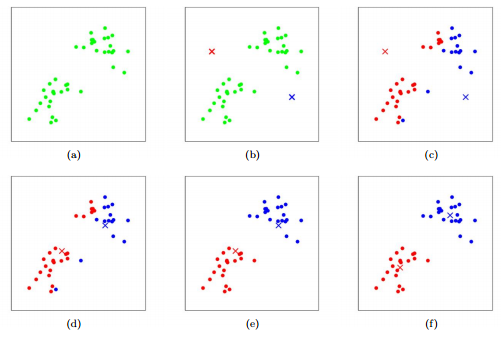

#### 2)

In [71]:
# k-means
km = KMeans(n_clusters=3)
y_pred = km.fit_predict(X)
df["3 clusters"] = km.labels_
display(df.head())

,uid,num_commits,AVG(diff),3 clusters
0,user_1,62,-64.400000,1
1,user_10,20,-74.800000,1
2,user_14,61,-159.000000,2
3,user_17,51,-61.600000,1
4,user_18,5,-5.666667,1


#### 3)

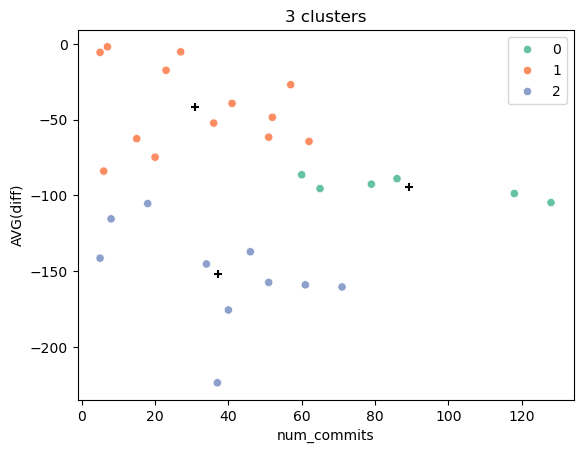

Точноcть для 3 кластеров: 0.4454402135233297


In [72]:
# plotting
sns.scatterplot(x="num_commits", y="AVG(diff)", data=df, hue=y_pred, palette='Set2')
plt.scatter(x=[points[0] for points in km.cluster_centers_], y=[points[1] for points in km.cluster_centers_], marker="+", color="black")    # цетроиды
plt.title("3 clusters")
plt.show()
df.drop(["3 clusters"], axis=1, inplace=True)
print(f"Точноcть для 3 кластеров: {silhouette_score(X, y_pred)}")


#### 4)

Посмотрим кластеризацию с разным количесвом классов:

Точноcть для 2 кластеров: 0.43623478911746133
Точноcть для 5 кластеров: 0.43029258712714447
Точноcть для 10 кластеров: 0.40259406273435566


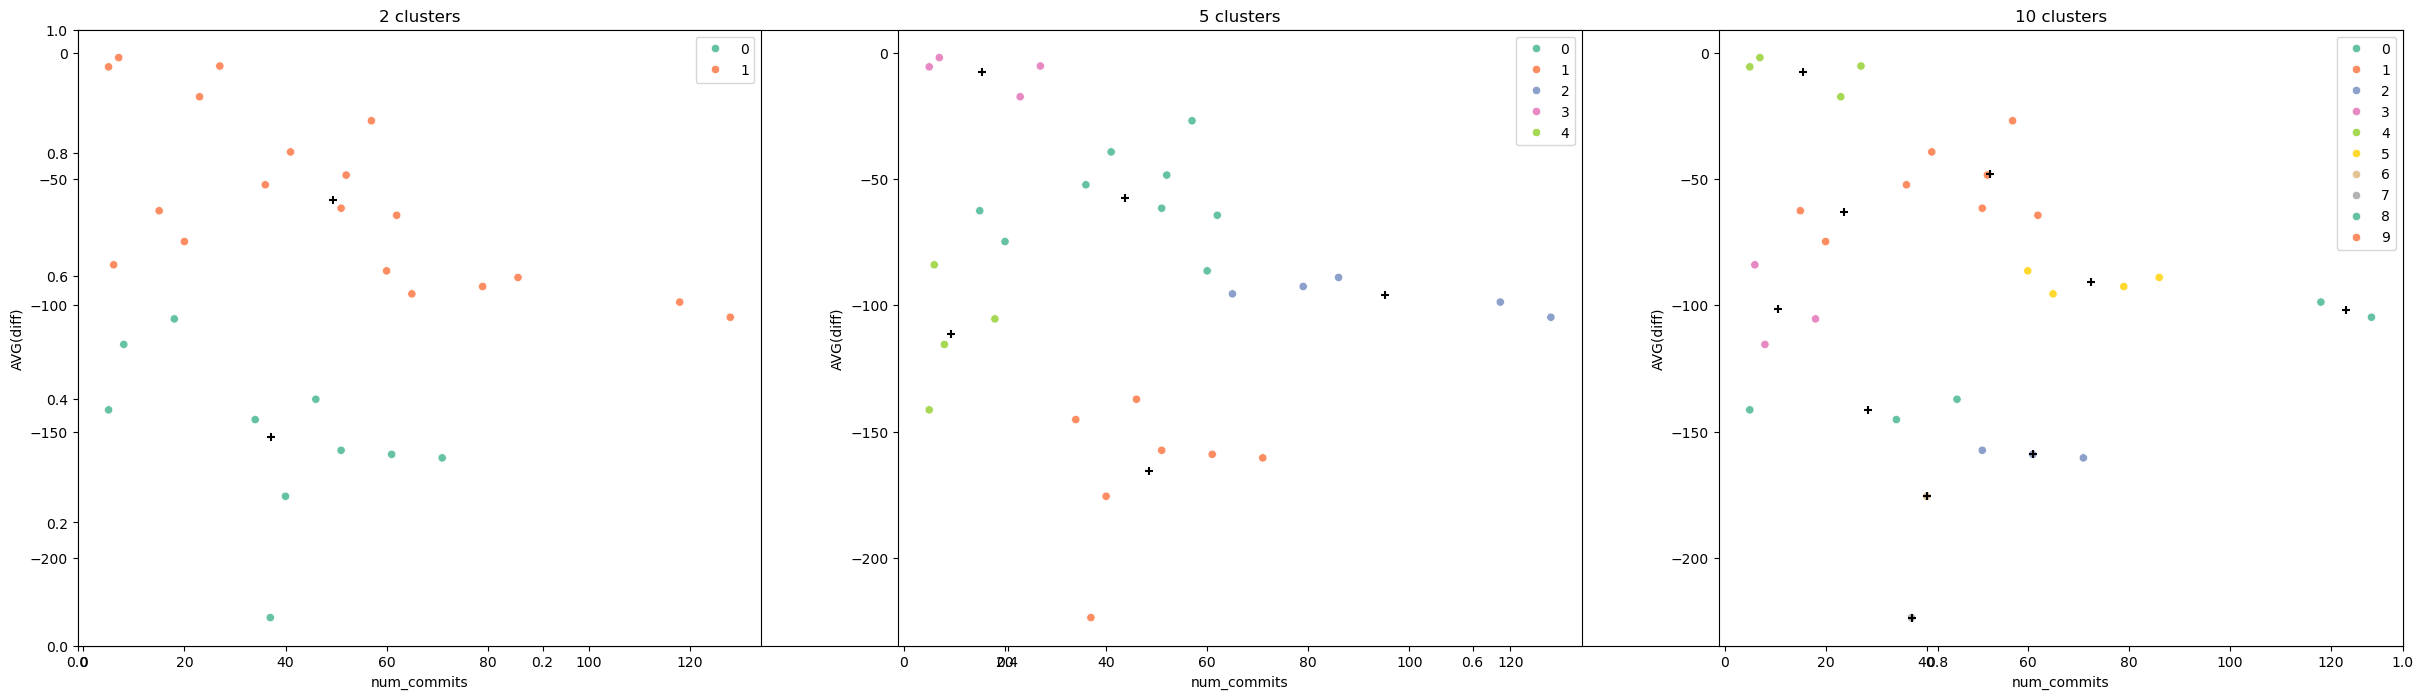

In [73]:
fig, ax = plt.subplots(figsize=(30, 8))
clusters = [2, 5, 10]
for c in clusters:
    km = KMeans(n_clusters=c)
    y_pred = km.fit_predict(X)
    df["cluster"] = km.labels_

    ax = plt.subplot(1, 3, clusters.index(c) + 1)
    sns.scatterplot(x="num_commits", y="AVG(diff)", data=df, hue=y_pred, palette='Set2')
    ax.scatter(x=[points[0] for points in km.cluster_centers_], y=[points[1] for points in km.cluster_centers_], marker="+", color="black")    # цетроиды
    plt.title(f"{c} clusters")
    print(f"Точноcть для {c} кластеров: {silhouette_score(X, y_pred)}")
    df.drop(["cluster"], axis=1, inplace=True)
plt.show()

Видно, что с увеличением количества кластеров, радиусы сужаются и центроиды некоторых классов совпадают с единственной точкой в них

#### 5)

__The Silhouette Coefficient__ is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b) for each sample.

По точности, которой была подсчитана выше, можно видеть, что учеличением кластеров привело к более точному разделению

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

#### 1)

Основанная на плотности пространственная кластеризация для приложений с шумами (англ. Density-based spatial clustering of applications with noise, __DBSCAN__) — это алгоритм кластеризации данных, который предложили Мартин Эстер, Ганс-Петер Кригель, Йёрг Сандер и Сюй Сяовэй в 1996. Это алгоритм кластеризации, основанной на плотности: если дан набор точек в некотором пространстве, алгоритм группирует вместе точки, которые тесно расположены (точки со многими близкими соседями), помечая как выбросы точки, которые находятся одиноко в областях с малой плотностью (ближайшие соседи которых лежат далеко). DBSCAN является одним из наиболее часто используемых алгоритмов кластеризации

#### 2)

In [74]:
db = DBSCAN(eps=20, min_samples=2)
y_pred = db.fit_predict(X)

#### 3)

Точноcть для 10 кластеров: 0.38339641455696616


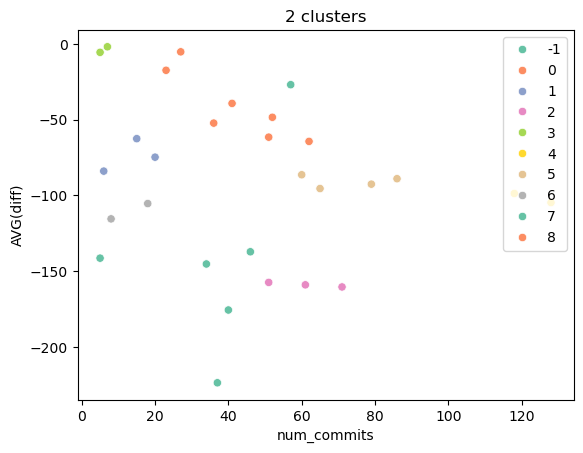

In [75]:
sns.scatterplot(x="num_commits", y="AVG(diff)", data=df, hue=y_pred, palette='Set2')
plt.title("2 clusters")
print(f"Точноcть для {c} кластеров: {silhouette_score(X, y_pred)}")


#### 4,5)

Точноcть для eps=5 min_samples=2: 0.2468241360324413
Точноcть для eps=10 min_samples=1: 0.09280988438126107
Точноcть для eps=25 min_samples=3: 0.3233351898184616
Точноcть для eps=30 min_samples=4: 0.37939165508577244
Точноcть для eps=40 min_samples=5: 0.2974765429800326


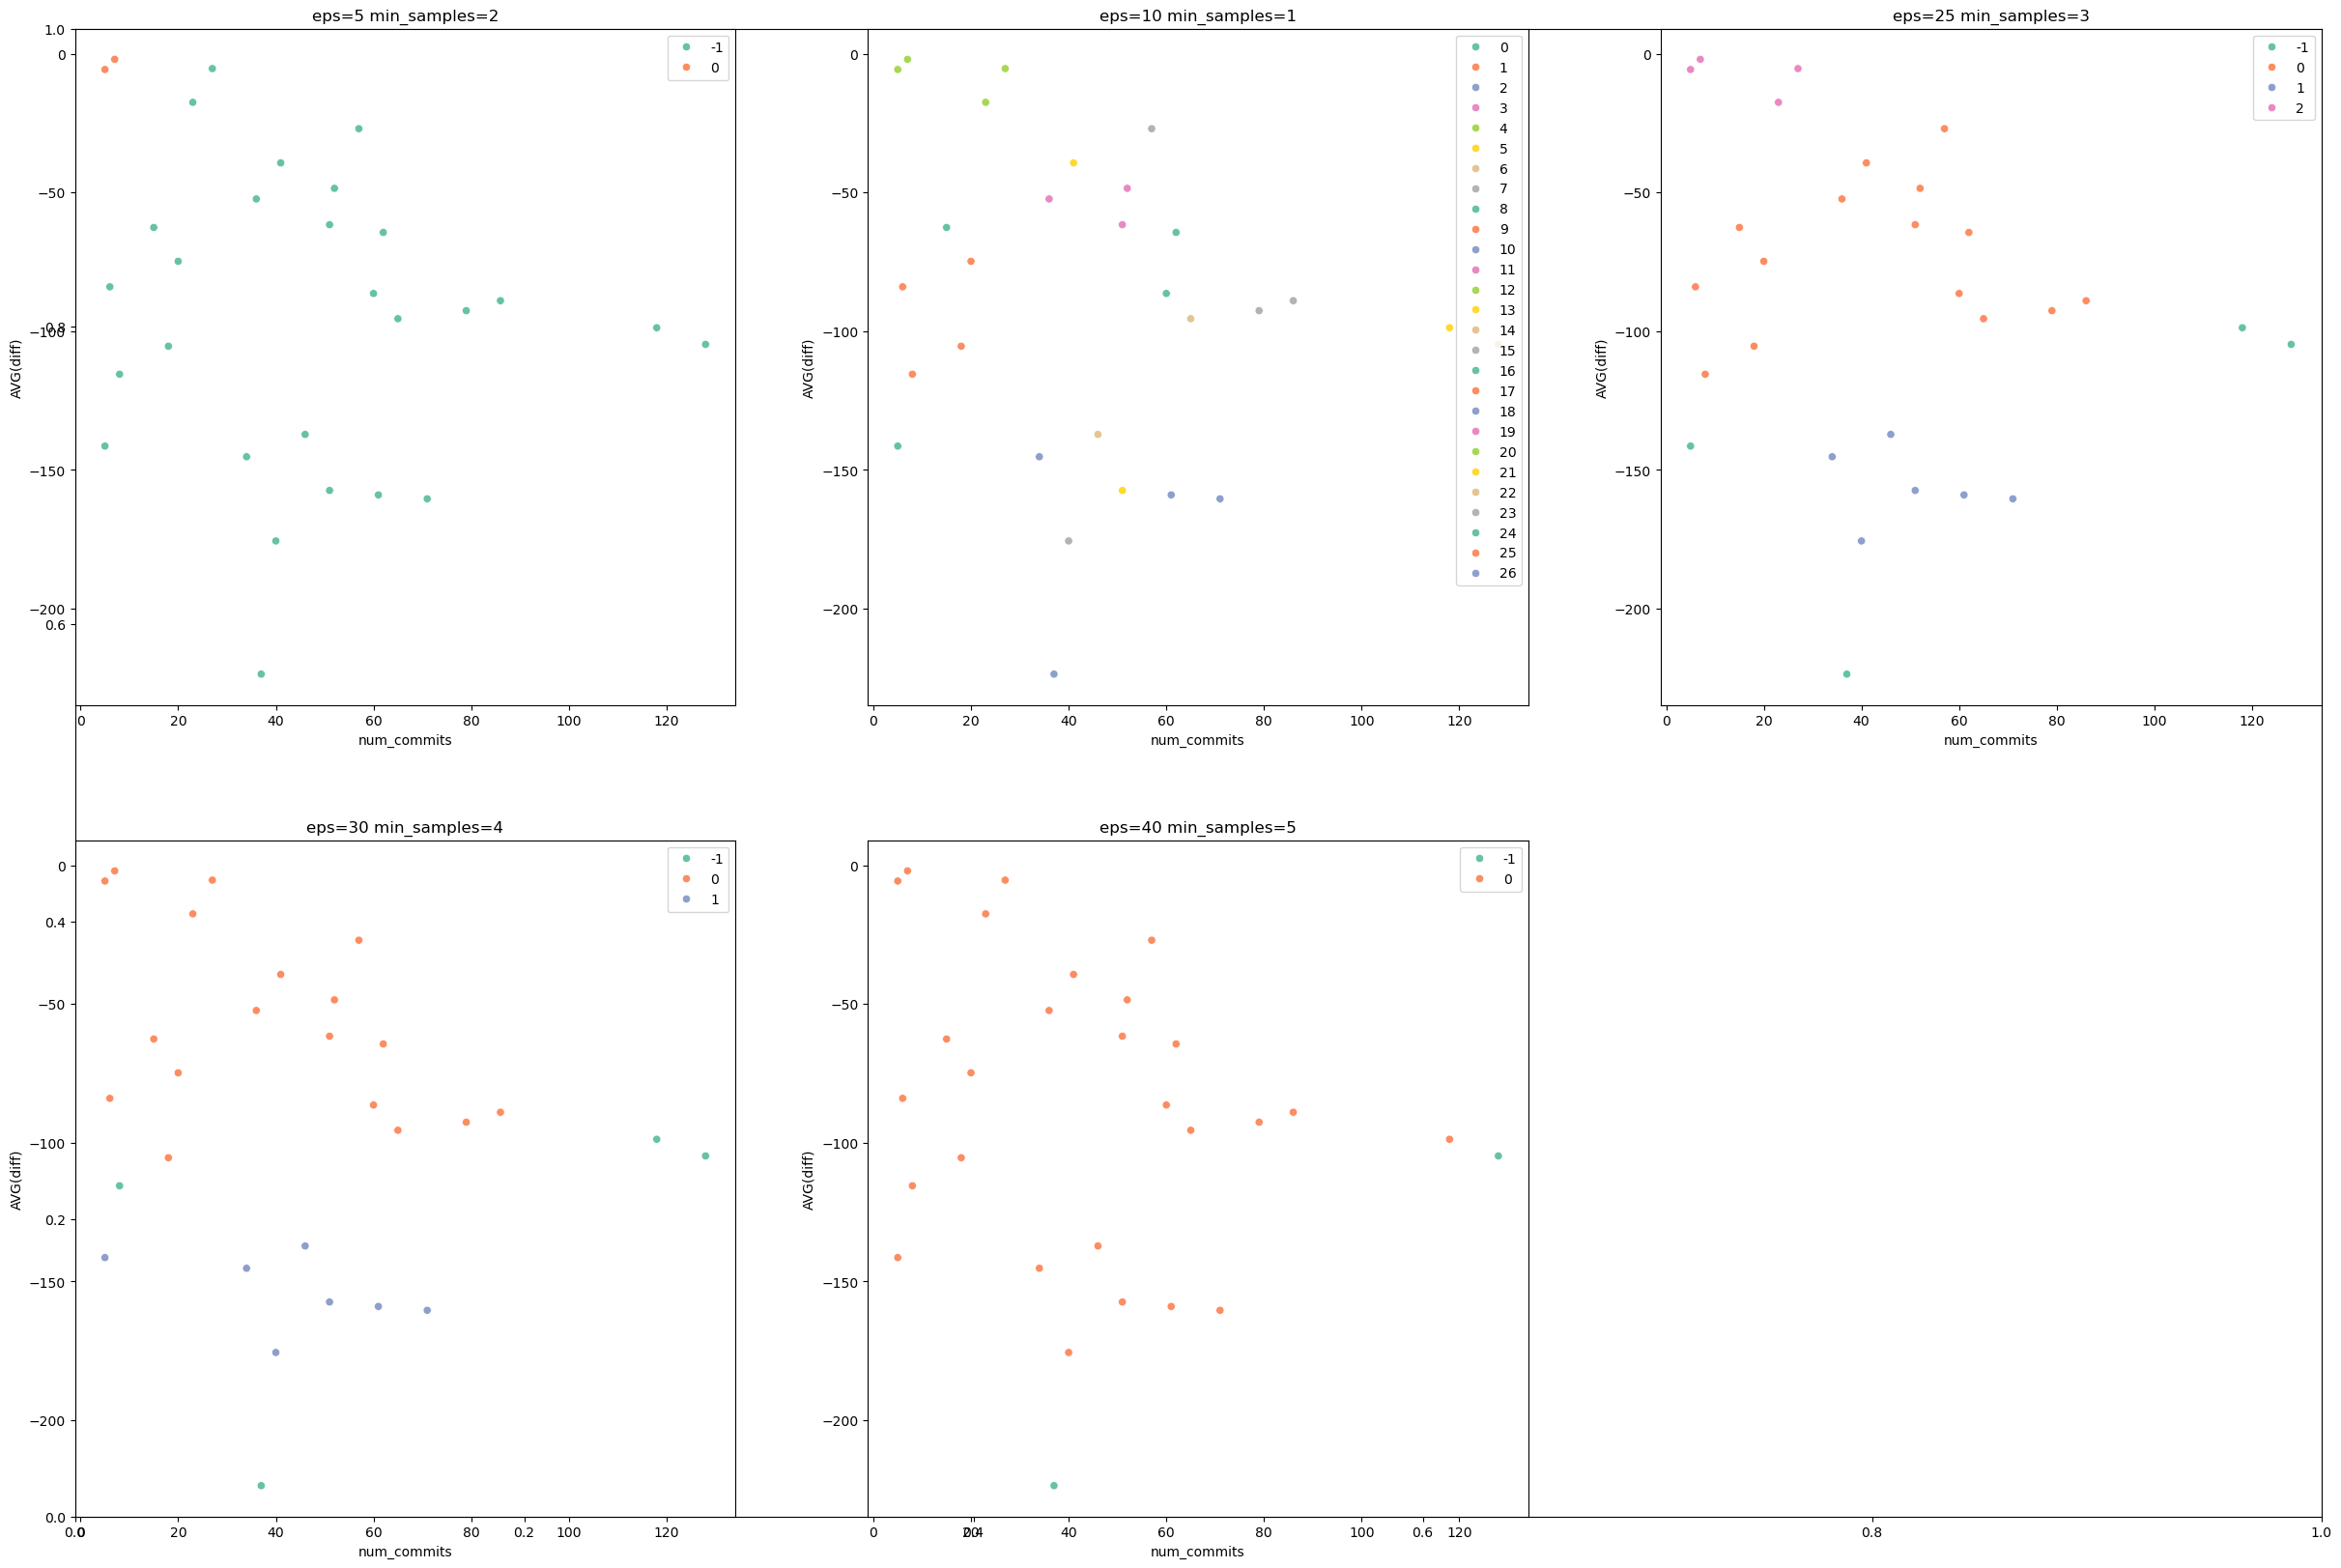

In [76]:
fig, ax = plt.subplots(figsize=(30, 20))
parameters = {5:2, 10:1, 25:3, 30:4, 40:5}
plot = 0
for eps in parameters:
    plot += 1
    samples = parameters[eps]
    db = DBSCAN(eps=eps, min_samples=samples)
    y_pred = db.fit_predict(X)

    ax = plt.subplot(2, 3, plot)
    sns.scatterplot(x="num_commits", y="AVG(diff)", data=df, hue=y_pred, palette='Set2')
    plt.title(f"eps={eps} min_samples={samples}")
    print(f"Точноcть для eps={eps} min_samples={samples}: {silhouette_score(X, y_pred)}")
plt.show()

Можно видеть, что уменьшение минимального количества точек в кластере коррелирует с количеством кластеров

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

#### 1)


__Hierarchical clustering__ is a technique used to group similar data points together based on their similarity creating a hierarchy or tree-like structure. The key idea is to begin with each data point as its own separate cluster and then progressively merge or split them based on their similarity. A __dendrogram__ is like a family tree for clusters. It shows how individual data points or groups of data merge together. The bottom shows each data point as its own group, and as you move up, similar groups are combined. The lower the merge point, the more similar the groups are.
*[Hierarchical Clustering in Machine Learning](https://www.geeksforgeeks.org/hierarchical-clustering/)

#### 2)

Точноcть для 5 кластеров: 0.46383015199381467


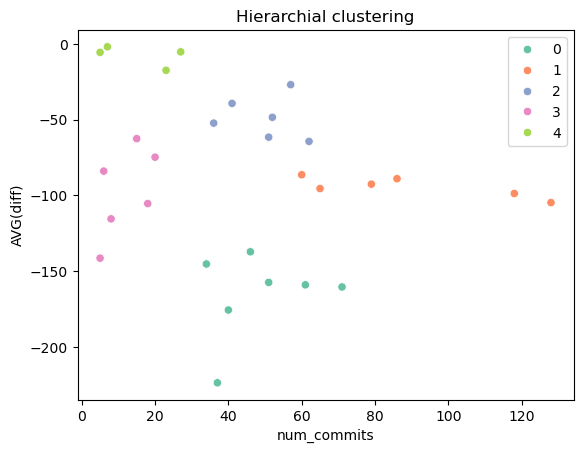

In [77]:
Agg = AgglomerativeClustering(n_clusters=5)
y_pred = Agg.fit_predict(X)
sns.scatterplot(x="num_commits", y="AVG(diff)", data=df, hue=y_pred, palette='Set2')
plt.title("Hierarchial clustering")
print(f"Точноcть для 5 кластеров: {silhouette_score(X, y_pred)}")

#### 3,4)

Точноcть для 2 кластеров: 0.35902490572221984
Точноcть для 6 кластеров: 0.4527145606287827
Точноcть для 10 кластеров: 0.431193930539333


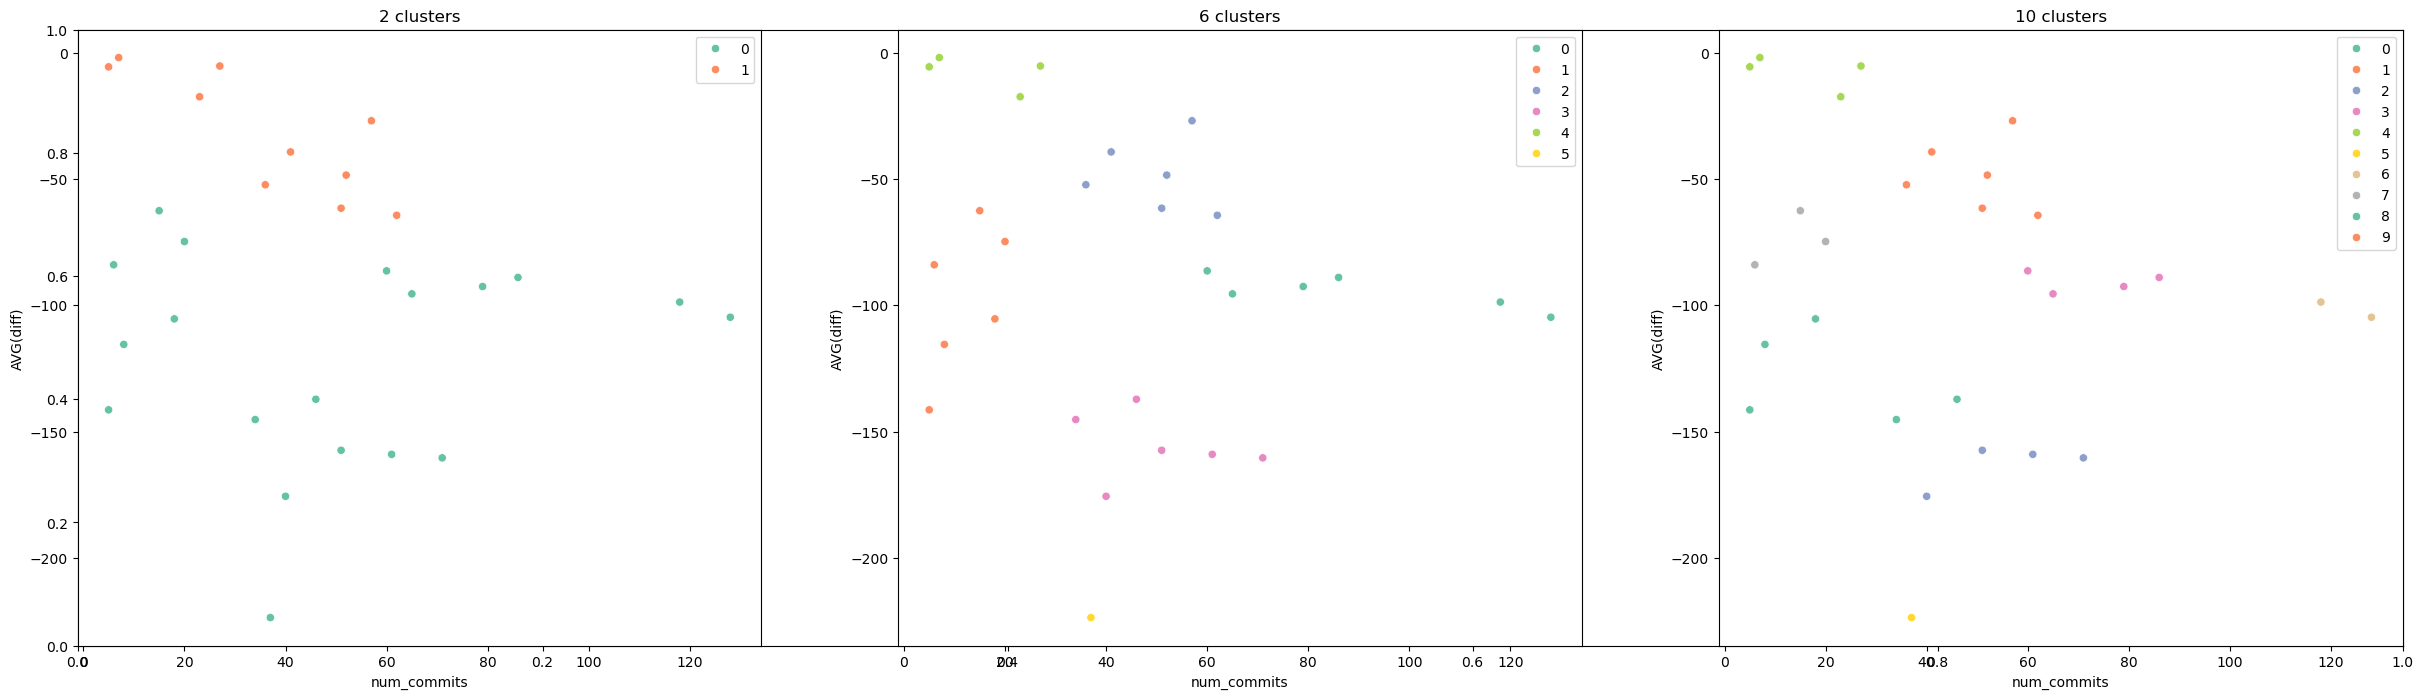

In [78]:
fig, ax = plt.subplots(figsize=(30, 8))
clusters = [2, 6, 10]
for c in clusters:
    Agg = AgglomerativeClustering(n_clusters=c)
    y_pred = Agg.fit_predict(X)

    ax = plt.subplot(1, 3, clusters.index(c) + 1)
    sns.scatterplot(x="num_commits", y="AVG(diff)", data=df, hue=y_pred, palette='Set2')
    #ax.scatter(x=[points[0] for points in km.cluster_centers_], y=[points[1] for points in km.cluster_centers_], marker="+", color="black")    # цетроиды
    plt.title(f"{c} clusters")
    print(f"Точноcть для {c} кластеров: {silhouette_score(X, y_pred)}")
plt.show()

#### 5)

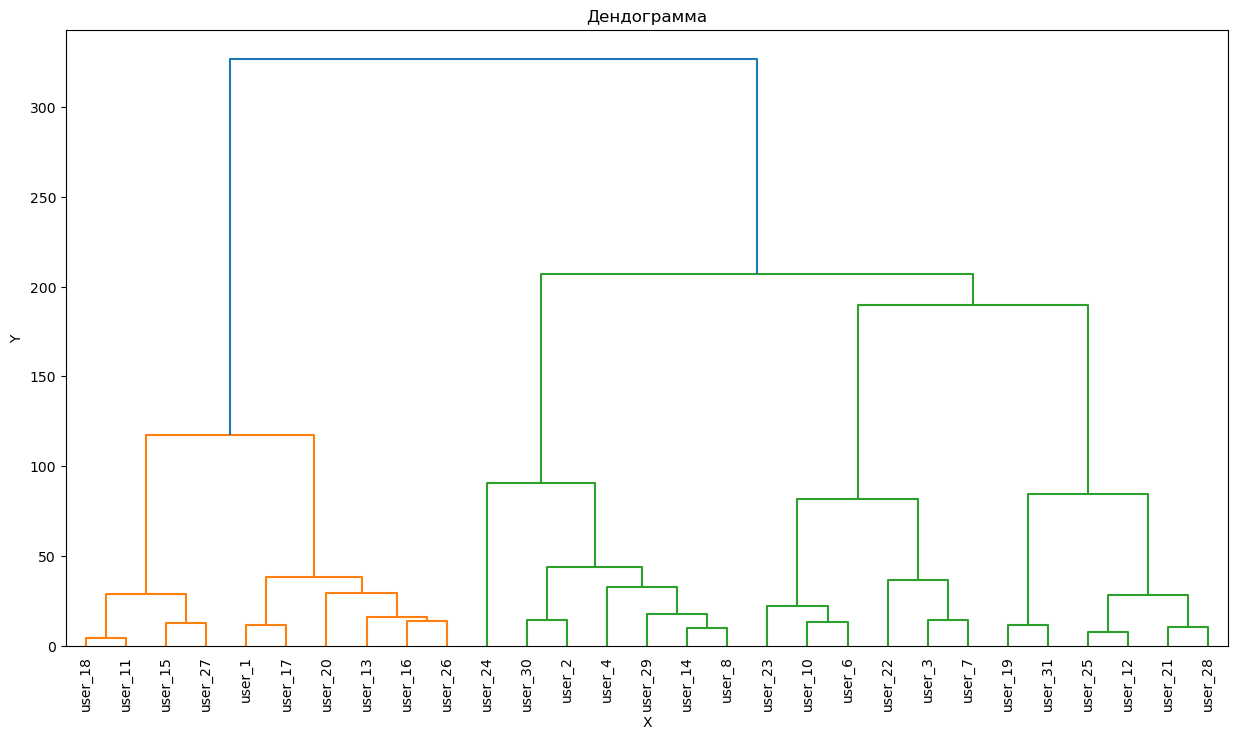

In [79]:
linkage_matrix = linkage(X, method='ward')  # структура связей между объектами (метод Уорда)

plt.subplots(figsize=(15, 8))
dendrogram(linkage_matrix, labels=df['uid'].values, leaf_rotation=90, leaf_font_size=10)
plt.title("Дендограмма")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [80]:
def func(model_class, opt_parametor, valid_range, X, **parameters):
    scores = []
    best_param = 0    # best value for opt_parametor
    for opt_p in valid_range:
        #del parameters[opt_p]
        parameters[opt_parametor] = opt_p
        model = model_class(**parameters)
        y_pred = model.fit_predict(X)
        if len(np.unique(y_pred)) > 1:  
            curr_score = silhouette_score(X, y_pred)
            scores.append(curr_score)
            if max(scores) == curr_score:
                best_param = opt_p

    return scores, best_param


print(func(model_class=DBSCAN, opt_parametor="eps", valid_range=range(25,35), X=X, min_samples=3))  # пример

([0.3233351898184616, 0.3233351898184616, 0.322261579137385, 0.322261579137385, 0.3634378956761896, 0.2936796540926391, 0.2936796540926391, 0.2936796540926391, 0.2936796540926391, 0.3659855186711519], 34)


Сделаем графики на примере DBSCAN (min_samples=2, 20 ≤ eps < 31):

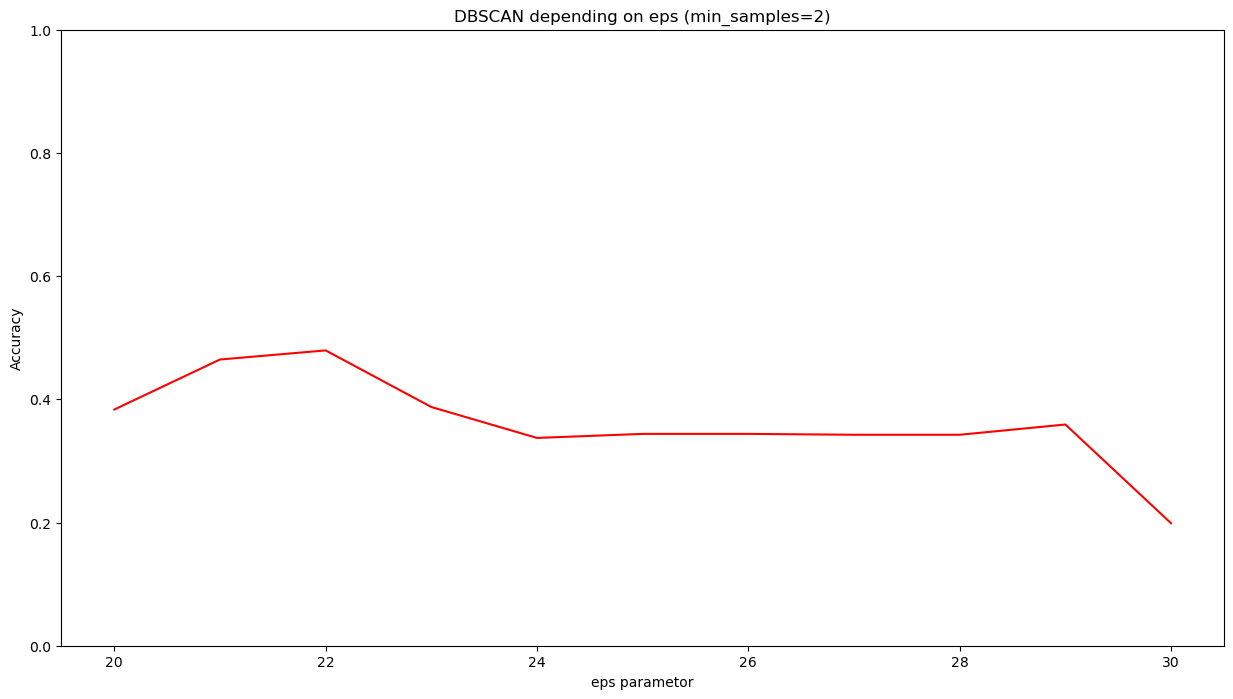

In [81]:
# first plot
fig, ax = plt.subplots(figsize=(15, 8))
scores = func(model_class=DBSCAN, opt_parametor="eps", valid_range=range(20, 31), X=X, min_samples=2)[0]
ax.plot(range(20, 31), scores, color="red")
plt.title("DBSCAN depending on eps (min_samples=2)")
ax.set_ylabel("Accuracy")
ax.set_xlabel("eps parametor")
ax.set_ylim([0,1])
plt.show()

Точноcть: 0.4794129092034348


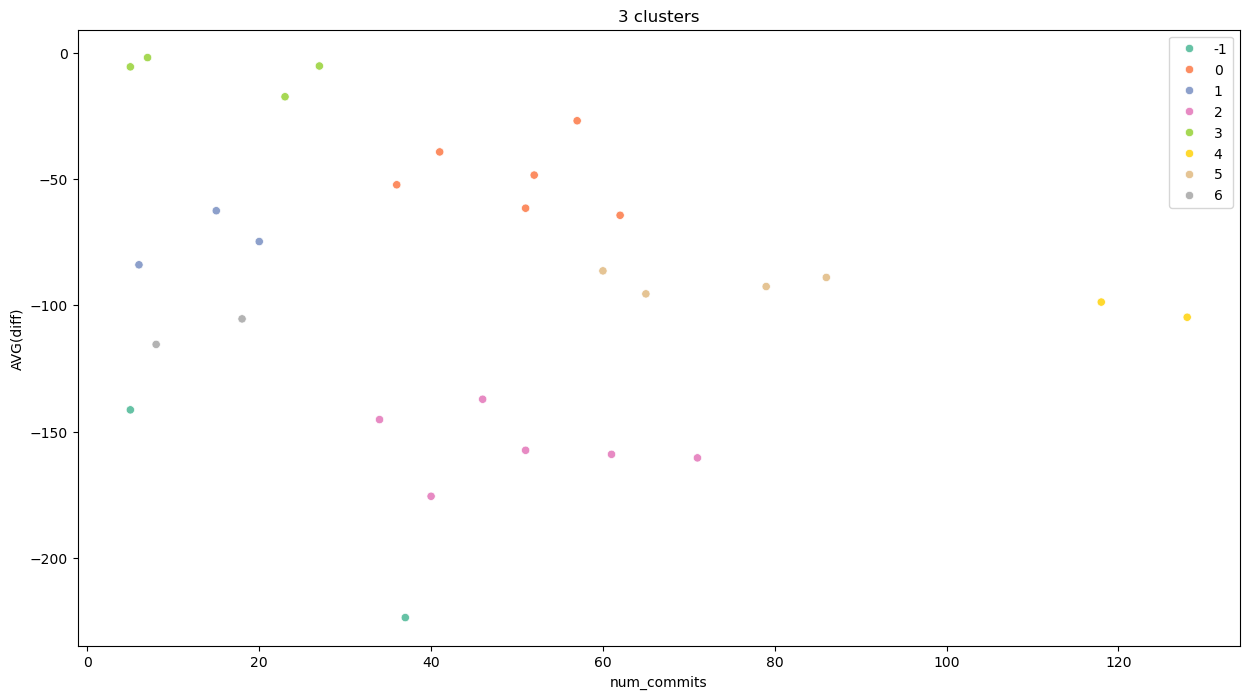

In [82]:
# second plt

fig, ax = plt.subplots(figsize=(15, 8))
best_p = func(model_class=DBSCAN, opt_parametor="eps", valid_range=range(20,31), X=X, min_samples=2)[1]

db = DBSCAN(eps=best_p, min_samples=2)
y_pred = db.fit_predict(X)
sns.scatterplot(x="num_commits", y="AVG(diff)", data=df, hue=y_pred, palette='Set2')
plt.title("3 clusters")
print(f"Точноcть: {silhouette_score(X, y_pred)}")
plt.show()

Посмотрим лучшие параметры для других моделей:


In [ ]:
# Kmeans
best_cluster = func(model_class=KMeans, opt_parametor="n_clusters", valid_range=range(1, 15), X=X, random_state=21)[1]
print(f"Kmeans: {best_cluster}")

# dbscan
best_eps = func(model_class=DBSCAN, opt_parametor="eps", valid_range=range(15, 31), X=X, min_samples=2)[1]
print(f"DBSACN (eps): {best_eps}")
best_min_samples = func(model_class=DBSCAN, opt_parametor="min_samples", valid_range=range(1, 10), X=X, eps=20)[1]
print(f"DBSCAN (min_samples): {best_min_samples}")

# Agglomerative Clustering
best_cluster = func(model_class=AgglomerativeClustering, opt_parametor="n_clusters", valid_range=range(1, 10), X=X)[1]
print(f"Agglomerative Clustering: {best_cluster}")

Kmeans: 8
DBSACN (eps): 22
DBSCAN (min_samples): 1
Agglomerative Clustering: 8
